# Single-Branch SimMIM HiRISE Reconstruction — Inspection

Loads a SimMIM checkpoint (`best_simim_25.pt`), samples random 1024×1024 crops from the crop index, runs masked reconstruction, and visualises **original · masked · reconstruction · composite · mask** side by side.

The model is the single-branch ConvNeXt-V2 / Swin `HybridEncoder` with a SimMIM head — there is no separate context branch.

In [11]:
# ── CUDA environment setup — must be the FIRST cell run in a fresh kernel ─────
#
# libcudnn.so.9 is not on LD_LIBRARY_PATH because the Jupyter kernel starts
# without the cluster module environment.  We load it via ctypes so that
# PyTorch's own dlopen call finds it already in the process symbol table.
#
# IMPORTANT: if you see any torch ImportError or AttributeError, do NOT re-run
# this cell — restart the kernel instead.  C extensions cannot be reloaded in
# the same process once they have been partially initialised.
#
import ctypes
import os
import sys

if 'torch' in sys.modules:
    raise RuntimeError(
        "torch is already imported — this cell must run before any import of torch.\n"
        "Restart the kernel (Kernel → Restart), then re-run from this cell."
    )

_CUDNN_PATH = '/is/software/nvidia/cudnn-9.10.2/lib/libcudnn.so.9'
if os.path.exists(_CUDNN_PATH):
    ctypes.CDLL(_CUDNN_PATH, mode=ctypes.RTLD_GLOBAL)
    print(f'Preloaded {_CUDNN_PATH}')
else:
    print('cuDNN not found — torch will try the system linker.')

RuntimeError: torch is already imported — this cell must run before any import of torch.
Restart the kernel (Kernel → Restart), then re-run from this cell.

In [12]:
!uv pip install matplotlib numpy

Checked 2 packages in 21ms


In [13]:
import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


def _find_vision_backend() -> Path:
    """Walk upward from cwd until we find vision_backend/model/hybrid_encoder.py."""
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'model' / 'hybrid_encoder.py').exists():
            return candidate          # cwd is already inside vision_backend/
        if (candidate / 'vision_backend' / 'model' / 'hybrid_encoder.py').exists():
            return candidate / 'vision_backend'
    raise RuntimeError(
        f"Cannot locate vision_backend/ from {start}. "
        "Run Jupyter from the repo root or from vision_backend/."
    )

VISION_BACKEND_DIR = _find_vision_backend()
PROJECT_ROOT = VISION_BACKEND_DIR.parent          # AI4ExoMars/

if str(VISION_BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(VISION_BACKEND_DIR))

print('vision_backend:', VISION_BACKEND_DIR)
print('project root  :', PROJECT_ROOT)

from model.hybrid_encoder import HybridEncoder
from model.simmim import SimMIMModel
from simmim_dataset import (
    SimMIMCropDataset,
    load_crop_records,
    load_splits,
    partition_records,
)

vision_backend: /Users/georgtirpitz/Library/CloudStorage/OneDrive-Persönlich/ESA/ExoMars/AI4ExoMars/vision_backend
project root  : /Users/georgtirpitz/Library/CloudStorage/OneDrive-Persönlich/ESA/ExoMars/AI4ExoMars


## Configuration

Edit paths and selection here. The model architecture is loaded from the checkpoint, so it always matches.

In [14]:
# ── Paths ────────────────────────────────────────────────────────────────────
# The SimMIM checkpoint lives at the AI4ExoMars repo root; the single-branch
# 1024x1024 crops + manifest live one level up under ../data.
CHECKPOINT_PATH = str(PROJECT_ROOT / 'best_simim_25.pt')
DATA_DIR        = PROJECT_ROOT.parent / 'data' / 'hirise_simmim_crops'
INDEX_PATH      = str(DATA_DIR / 'crops_index.csv')
SPLITS_PATH     = str(DATA_DIR / 'splits.json')

# ── Selection ────────────────────────────────────────────────────────────────
SPLIT      = 'val'    # 'val' | 'train' | 'all' — which crops to sample from
USE_EMA    = True     # load the EMA weights (smoother) instead of raw model_state
BATCH_SIZE = 4

# ── Visualisation ─────────────────────────────────────────────────────────────
NUM_CROPS = 6   # random crops to display
SEED      = 0

# The model architecture is read directly from the checkpoint's saved config
# (see the "Build Model" cell), so there is no hand-maintained MODEL_CONFIG to
# keep in sync here.

## Device

In [15]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.manual_seed_all(SEED)
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('device:', device)

device: mps


## Load Crop Index

In [16]:
records = load_crop_records(INDEX_PATH)

if SPLIT in ('train', 'val'):
    splits = load_splits(SPLITS_PATH)
    train_recs, val_recs = partition_records(records, splits)
    selected = {'train': train_recs, 'val': val_recs}[SPLIT]
else:
    selected = records

by_obs = Counter(r.observation_id for r in selected)
print(f'Split           : {SPLIT}')
print(f'Crops available : {len(selected)}  (of {len(records)} total)')
print(f'Observations    : {len(by_obs)}')
for obs, n in sorted(by_obs.items()):
    print(f'  {obs}  ({n} crops)')

Split           : val
Crops available : 2685  (of 30675 total)
Observations    : 4
  ESP_070092_2000_RED  (632 crops)
  ESP_070237_1990_RED  (694 crops)
  PSP_001558_1325_RED  (168 crops)
  PSP_001666_1530_RED  (1191 crops)


## Build Model and Load Checkpoint

In [17]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
mc = checkpoint.get('config', {}).get('model', {})

# Build the encoder + SimMIM head to match the architecture recorded in the
# checkpoint. use_checkpoint is forced off — gradient checkpointing is a
# train-only memory optimisation and is irrelevant for inference.
encoder = HybridEncoder(
    in_channels=mc.get('in_channels', 1),
    global_base_grid=mc.get('global_base_grid', 32),
    window_size=mc.get('window_size', 8),
    drop_path=mc.get('drop_path', 0.0),
    use_checkpoint=False,
)
model = SimMIMModel(
    encoder,
    in_channels=mc.get('in_channels', 1),
    mask_unit=mc.get('mask_unit', 32),
    mask_ratio=mc.get('mask_ratio', 0.4),
    loss_type=mc.get('loss_type', 'l1'),
).to(device)

print(f'Parameters     : {sum(p.numel() for p in model.parameters()):,}')
print(f'Mask unit      : {model.mask_unit}px  ·  mask ratio: {model.masker.mask_ratio}')
print(f'Recorded config: {mc}')

Parameters     : 28,443,065
Mask unit      : 32px  ·  mask ratio: 0.4
Recorded config: {'in_channels': 1, 'global_base_grid': 32, 'window_size': 8, 'drop_path': 0.198, 'use_checkpoint': True, 'mask_unit': 32, 'mask_ratio': 0.4, 'loss_type': 'l1'}


In [18]:
state_key = 'ema_state' if (USE_EMA and 'ema_state' in checkpoint) else 'model_state'
state_dict = checkpoint[state_key]

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f'Loaded "{state_key}" from {Path(CHECKPOINT_PATH).name}')
if missing:
    print(f'  Missing keys ({len(missing)}):', missing[:5], '...' if len(missing) > 5 else '')
if unexpected:
    print(f'  Unexpected keys ({len(unexpected)}):', unexpected[:5], '...' if len(unexpected) > 5 else '')
if not missing and not unexpected:
    print('  Checkpoint loaded cleanly.')

for info_key in ('stage', 'step', 'epoch', 'best_val_loss', 'val_loss'):
    if info_key in checkpoint:
        print(f'  {info_key}: {checkpoint[info_key]}')

model.eval();

Loaded "ema_state" from best_simim_25.pt
  Checkpoint loaded cleanly.
  stage: stage1_simmim
  step: 440


## Random Crops

Samples `NUM_CROPS` random crops from the selected split and shows them — no model involved.

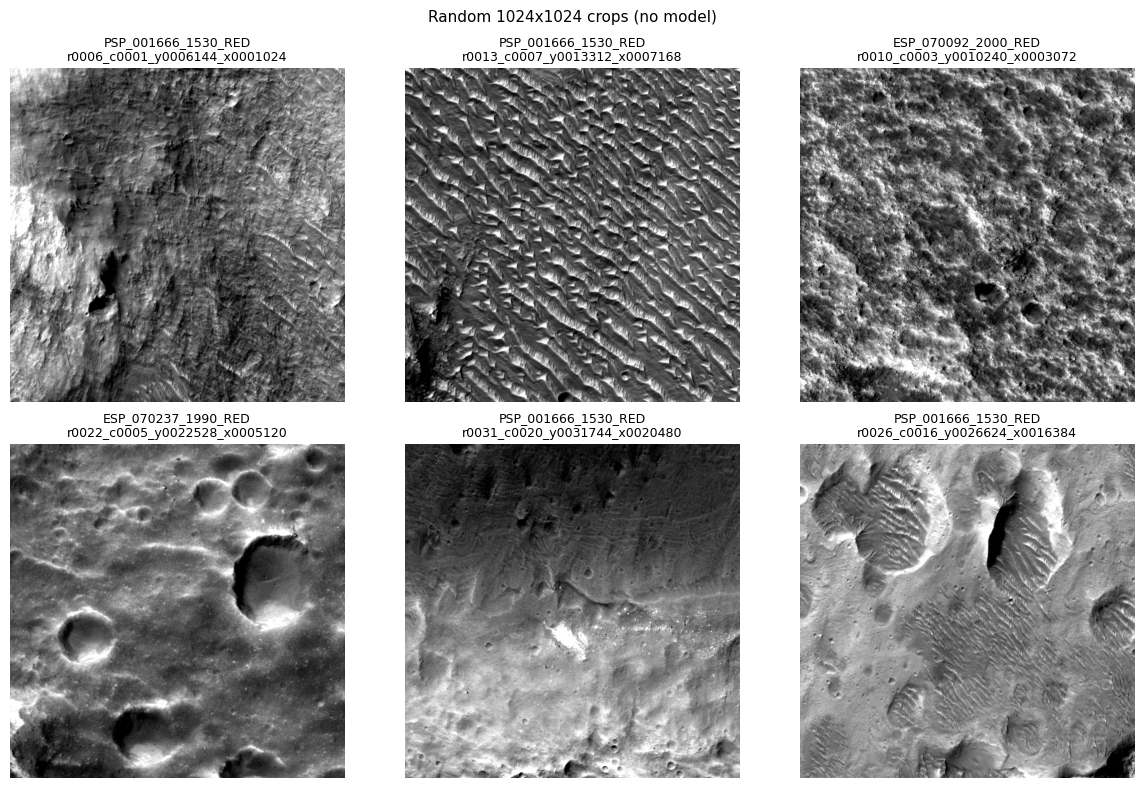

In [19]:
def to_display(t, mode: str = 'signed') -> np.ndarray:
    """Convert a (1, H, W) / (H, W) tensor to a [0, 1] grayscale image.

    mode='signed'  : crops live in [-1, 1] (uint8/127.5 - 1) -> map to [0, 1]
    mode='stretch' : robust 1-99 percentile stretch (for arbitrary ranges)
    mode='raw'     : assume already in [0, 1] (e.g. boolean masks)
    """
    img = t.squeeze().detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)
    img = np.asarray(img, dtype=np.float32)
    if mode == 'signed':
        return np.clip((img + 1.0) / 2.0, 0.0, 1.0)
    if mode == 'stretch':
        finite = img[np.isfinite(img)]
        if finite.size == 0:
            return np.zeros_like(img)
        lo, hi = float(np.percentile(finite, 1.0)), float(np.percentile(finite, 99.0))
        if hi <= lo:
            lo, hi = float(finite.min()), float(finite.max())
        if hi <= lo:
            return np.zeros_like(img)
        return np.clip((img - lo) / (hi - lo), 0.0, 1.0)
    return np.clip(img, 0.0, 1.0)


def show(ax, t, title: str = '', mode: str = 'signed') -> None:
    ax.imshow(to_display(t, mode), cmap='gray', vmin=0, vmax=1)
    if title:
        ax.set_title(title, fontsize=9)
    ax.axis('off')


def crop_label(rec) -> str:
    name = Path(rec.crop_path).stem
    tail = name.split('_RED')[-1].lstrip('_') or name
    return f'{rec.observation_id}\n{tail}'


rng = random.Random(SEED)
sampled = rng.sample(selected, min(NUM_CROPS, len(selected)))
dataset = SimMIMCropDataset(sampled, augment=False)

cols = min(3, len(sampled))
rows = (len(sampled) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_1d(axes).ravel()
for i, rec in enumerate(sampled):
    show(axes[i], dataset[i]['image'], crop_label(rec))
for j in range(len(sampled), len(axes)):
    axes[j].axis('off')
fig.suptitle('Random 1024x1024 crops (no model)', fontsize=11)
plt.tight_layout()
plt.show()

## Masked Reconstruction

Runs the loaded SimMIM model on the sampled crops. **Composite** = original where visible, reconstruction where masked; the masked-region loss is reported in the title.

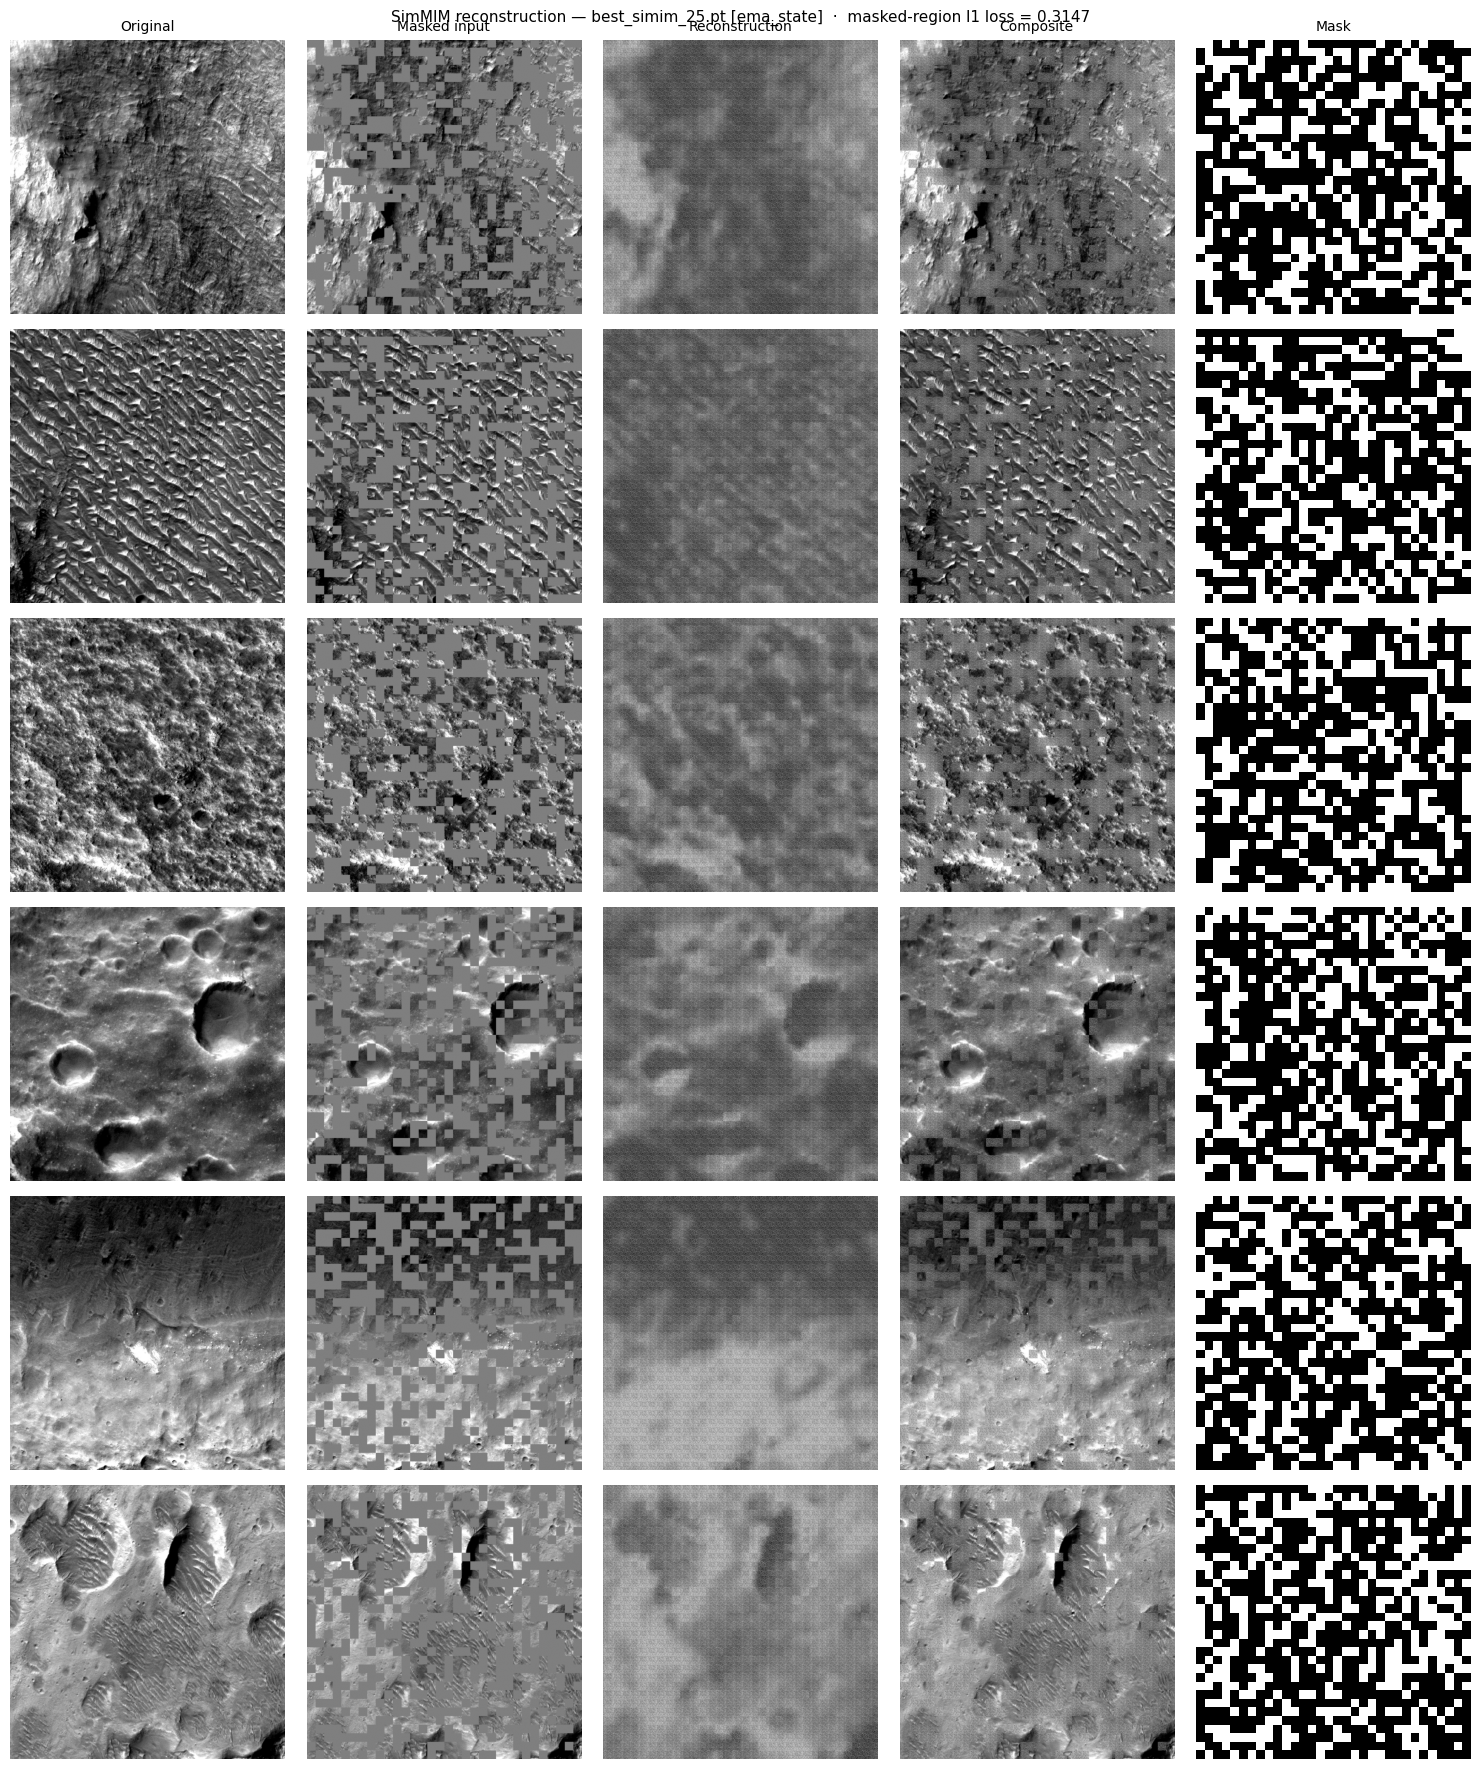

In [20]:
@torch.no_grad()
def reconstruct(records_subset, *, seed: int):
    """Run SimMIM on a list of crop records and return display-ready panels."""
    ds = SimMIMCropDataset(records_subset, augment=False)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    orig, masked, recon, comp, masks, losses = [], [], [], [], [], []
    model.eval()
    # Deterministic masks so reruns of the same seed are reproducible.
    torch.manual_seed(seed)
    for batch in loader:
        x = batch['image'].to(device).float()
        out = model(x)
        # Upsample the (B, gh, gw) unit mask to pixel resolution and build a
        # composite: original where visible, reconstruction where masked.
        m_px = F.interpolate(
            out['mask'].float().unsqueeze(1),
            scale_factor=model.mask_unit,
            mode='nearest',
        )
        composite = x * (1.0 - m_px) + out['reconstruction'].float() * m_px

        orig.extend(x.cpu())
        masked.extend(out['masked_input'].float().cpu())
        recon.extend(out['reconstruction'].float().cpu())
        comp.extend(composite.cpu())
        masks.extend(out['mask'].cpu())
        losses.append(float(out['loss']))
    return orig, masked, recon, comp, masks, float(np.mean(losses))


def plot_reconstruction(panels, *, title: str):
    orig, masked, recon, comp, masks, mean_loss = panels
    col_titles = ['Original', 'Masked input', 'Reconstruction', 'Composite', 'Mask']
    n = len(orig)
    fig, axes = plt.subplots(n, len(col_titles), figsize=(3 * len(col_titles), 3 * n))
    axes = np.atleast_2d(axes)
    for ci, ct in enumerate(col_titles):
        axes[0, ci].set_title(ct, fontsize=10)
    for ri in range(n):
        show(axes[ri, 0], orig[ri],   mode='signed')
        show(axes[ri, 1], masked[ri], mode='signed')
        show(axes[ri, 2], recon[ri],  mode='signed')
        show(axes[ri, 3], comp[ri],   mode='signed')
        show(axes[ri, 4], masks[ri],  mode='raw')
    fig.suptitle(f'{title}  ·  masked-region {model.loss_type} loss = {mean_loss:.4f}', fontsize=11)
    plt.tight_layout()
    plt.show()


panels = reconstruct(sampled, seed=SEED)
plot_reconstruction(
    panels,
    title=f'SimMIM reconstruction — {Path(CHECKPOINT_PATH).name} [{state_key}]',
)

## Re-sample and Re-run

Run the cell below to draw a fresh random seed and re-run the reconstruction on a new set of crops.

In [ ]:
import time

new_seed = int(time.time()) % 10_000
print(f'New seed: {new_seed}')

rng2 = random.Random(new_seed)
sampled2 = rng2.sample(selected, min(NUM_CROPS, len(selected)))

panels2 = reconstruct(sampled2, seed=new_seed)
plot_reconstruction(panels2, title=f'SimMIM reconstruction (seed={new_seed})')